# libraries


In [1]:
import pandas as pd
import numpy as np
import math
from math import floor
import scipy
import matplotlib.pyplot as plt
import sklearn 
import xarray as xr
from sklearn.tree import DecisionTreeRegressor
import matplotlib.patches as mpl_patches

from sklearn.model_selection import train_test_split , LeaveOneOut, cross_val_score
cv=LeaveOneOut()
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #utilisé pour supprimer la moyenne et mettre les caractéristiques 
#à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
# dominent le modèle en raison de différences d'échelle.
# Import LinearRegression.
from sklearn.linear_model import LinearRegression
# Import metrics.
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

import os

os.chdir('C:/Users/leoge/OneDrive/Documents/Centrale Nantes/ei4/R&D')

## functions

In [2]:
def cross_score(model, X, y ):
        """ Arguments 
        - model
        - X features
        - y target
        Returns
        cross val score for R-squared (r2), 
        mean absolute value (mae),
        mean square error (mse),
        root mean squared error (rmse)
        """
        from sklearn.model_selection import LeaveOneOut, cross_val_score
        cv=LeaveOneOut()
        r2=cross_val_score(model,X,y, scoring='r2',cv=cv,n_jobs=-1)

        mae=cross_val_score(model,X,y,
                            scoring='neg_mean_absolute_error',
                            cv=cv, 
                            n_jobs=-1) 
        mse=cross_val_score(model,X,y,
                                scoring='neg_mean_squared_error',
                                cv=cv,
                                n_jobs=-1)
        rmse=cross_val_score(model,X,y,
                                scoring='neg_root_mean_squared_error',
                                cv=cv,
                                n_jobs=-1)

        df=pd.DataFrame(data={'r2':r2,'mae':mae,'mse':mse,'rmse':rmse})
        return df

In [3]:
def LinearRegression_sklearn(df_data,X_features,y_target_name,state_random=42,split_random=True,time_split=100,size_test=0.25):
    '''
    Arguments :
    - df_data : dataframe of the data with all features wanted and targets
    - X_features : name of features as list or array
    - y_target_name : name of target value to predict
    Returns : 
    - [df_model, df_model_train,y_pred, y_train, y_test, b, coeff_df, [r2,mae,mse,rmse]]
    - df_model : model timeseries for df_data['Age']
    - df_model_train : model for train set
    - y_pred : model for test set
    - b : model intercept
    - coeff_df : model's coefficient
    - [r2,mae,mse,rmse] : model's performance
    '''
    # Import train_test_split.
    from sklearn.model_selection import train_test_split , LeaveOneOut, cross_val_score
    cv=LeaveOneOut()
    # Import StandardScaler.
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler() #utilisé pour supprimer la moyenne et mettre les caractéristiques 
    #à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
    # dominent le modèle en raison de différences d'échelle.
    # Import LinearRegression.
    from sklearn.linear_model import LinearRegression
    # Import metrics.
    from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
    
    features = X_features
    # df_data.columns[1:-3].append(df_data_diff.columns[1:-3]).values
    y_target=[y_target_name] #,'FF_Mean_diff','FS_Mean','FS_Mean_diff']

    df_dataa=df_data[1:]
    for k in range(len(y_target)):
        X = df_dataa[features]
        y = df_dataa[y_target[k]]
        # Create features X and target y.

        # Split the dataset into training (usually 75%) and testing (25%) sets.
        if split_random==True:
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size_test, random_state=state_random)
        else:
            tt=time_split
            X_train, X_test, y_train, y_test = X[:tt],X[tt:],y[:tt],y[tt:]

        # Fit and transform training data.
        X_scaled = scaler.fit_transform(X)
        X_train_scaled = scaler.transform(X_train)   # X_train
        X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
        # Also transform test data.
        X_test_scaled = scaler.transform(X_test)    # X_test 
        X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)

        # Instantiate linear regression model.
        model = LinearRegression()
        # Fit the model to the training data.
        model.fit(X_train_scaled, y_train)

        # Make predictions on the testing data.
        y_pred = model.predict(X_test_scaled)
        # coefficient of model
        b=model.intercept_
        coeff_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
        # train vs model data
        df_model_train=X_train_scaled
        # multiply all columns with their respective coefficient
        for i in range(len(coeff_df.Coefficient)):
            df_model_train.iloc[:,i] = X_train_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]
        # add all columns 
        df_model_train = df_model_train.sum(axis=1)
        #### dataframe of obtained model
        df_model=X
        X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

        # multiply all columns with their respective coefficient
        for i in range(len(coeff_df.Coefficient)):
            df_model.iloc[:,i] = X_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]
        # add all columns 
        df_model = df_model.sum(axis=1)

        [r2,mae,mse,rmse]=[r2_score(y, b+df_model),
                        abs(cross_score(model,X,y)).mean()[1],
                        abs(cross_score(model,X,y)).mean()[2],
                        abs(cross_score(model,X,y)).mean()[3]]


        return df_model, df_model_train, y_pred, y_train, y_test, b, coeff_df, [r2,mae,mse,rmse],X_scaled
        


# SETUP

## setup definition

In [4]:
# time span
time_range_min=-12000 #a cal. years BP
time_range_max=0   #in cal. years BP 0 = 1950 AD (Anno Domini: "après JC")
# spatial span ; span used in the paper
lat_min,lat_max=45,55 # degree north
lon_min,lon_max=90,100 # degree east

# measurments lakes
lakes=['M14','M15','O6','O14','O15','O16']
lat=[50.0755555556,49.7858333333,49.8213888889,50.0283333333,50.0080555556,50.0186111111]
lon=[-95.4022222222,-95.1902777778,-94.7836111111,-94.8244444444,-94.9825,-94.8508333333]
altitude=[330,337,361,332,339,337]
measurments=pd.DataFrame({'Lake':lakes,'lat':lat,'lon':lon,'altitude':altitude})

lat_meas=measurments.describe().loc['mean'].lat
lon_meas=measurments.describe().loc['mean'].lon
lat_meas,lon_meas #degree north, degree east

time_resolution= 50 #in a cal. years BP
time_array=np.arange(time_range_min,time_range_max+time_resolution,time_resolution ) #in cal. years BP

roll_window=10
size_test=0.25


## Load PRECT and TS data

In [5]:

#Precipitation rate #decadal mean annual # averages 22ka-2000AD 
#PRECT = Total precipitation rate: PRECC+PRECL #PRECC = Convective precipitation rate #PRECL = Large-scale (stable) precipitation rate
PRECT = xr.open_dataset(
    './climate_data/TraCE-21K-II.ann.PRECT.nc')
PRECT = PRECT.sel(lat=lat_meas,lon=360+lon_meas,method='nearest') # select pixel of interest of dataset
PRECT=PRECT.rename({'time':'Age'})
PRECC = pd.DataFrame({'Age':PRECT.Age.values*1000,'PRECC':PRECT.PRECC.values})
PRECL = pd.DataFrame({'Age':PRECT.Age.values*1000,'PRECL':PRECT.PRECL.values})
PRECT = pd.DataFrame({'Age':PRECT.Age.values*1000,'PRECT':PRECT.PRECT.values})

#Temperature Surface
TS = xr.open_dataset(
    './climate_data/TraCE-21K-II.ann.TS.nc')
TS = TS.sel(lat=lat_meas,lon=360+lon_meas,method='nearest') # select pixel of interest
TS=TS.rename({'time':'Age'})
TS = pd.DataFrame({'Age':TS.Age.values*1000,'TS':TS.TS.values})

AnnTemp = pd.read_csv('./25155593/AnnTemp.csv')
AnnTemp=AnnTemp[['Age','AnnTemp']].dropna()
AnnTemp = AnnTemp.reindex(index=AnnTemp.index[::-1]).reset_index(drop=True)
AnnTemp.Age=AnnTemp.Age*(-1)
Human = pd.read_csv('./25155593/Human.csv')
Human = Human.reindex(index = Human.index[::-1]).reset_index(drop=True)
Human.Age = Human.Age /(-1) #conversion to 12000 to 0 

## Load fire data

In [6]:
# Fire frequency
FF = pd.read_csv('./25155593/FFBootCISap.csv')
FF= FF.reindex(index=FF.index[::-1]).reset_index(drop=True)
FF.Age = FF.Age /(-1)
# burning biomass
BB = pd.read_csv('./25155593/BBBootCISap.csv')
BB = BB.reindex(index=BB.index[::-1]).reset_index(drop=True)
BB.Age = BB.Age/(-1)
#FS = FF/BB
FS = pd.read_csv('./25155593/FSBootCISap.csv')
FS = FS.reindex(index=FS.index[::-1]).reset_index(drop=True)
FS.Age = FS.Age/(-1)

FF=FF.rename(columns={'Mean':'FF_Mean'})
FS=FS.rename(columns={'Mean':'FS_Mean'})
BB=BB.rename(columns={'Mean':'BB_Mean'})

## Load environmental data

créer le dataframe Age, TS, PRECT, human et dataframe BB, FF , FS



interpolation sur time array -12000 à 0 years cal. BP avec pas de 50 ans

merge les 2 dataframes en 1 df_annual

In [7]:
list_vars=['TS','PRECT','human'] # ,'PRECC','PRECL'
list_df=[TS,PRECT,Human] # ,PRECC,PRECL

dict={'Age':time_array}
for i in range (len(list_vars)):
    f_interp = np.interp(time_array,list_df[i].Age.values,list_df[i][list_vars[i]].values)
    mean_3_to_5_ka= list_df[i].loc[(list_df[i].Age < -3000) & (list_df[i].Age > -5000)][list_vars[i]].mean()
    f_interp = f_interp - mean_3_to_5_ka
    dict.update({list_vars[i]:f_interp})

list_df=[BB,FF,FS]
list_var= ['BB_Mean','FF_Mean','FS_Mean']
dict2={'Age':time_array}
n=len(list_df)
for i in range (0,n):
    f_interp = np.interp(time_array,list_df[i].Age.values,list_df[i][list_var[i]].values)
    dict2.update({list_var[i]:f_interp})

dict.update(dict2)

df_annual = pd.DataFrame(dict)
df_annual.Age = time_array # convert -12 ka to 12000 cal. years BP

# lissage des données par moyenne glissante sur valeur(roll_window)  pas de temps (moyenne glissante sur 10 pdt. )
df_annual = df_annual.rolling(window=roll_window).mean()


## Load pollen data

creation dataframe des données pollen, interpolation sur time array, lissage par moyenne glissante sur roll_window pas de temps

In [8]:
Pollen50Reg = pd.read_csv('./25155593/Pollen50Reg.csv')
Pollen50Reg
pollen = Pollen50Reg

cols_pollen=Pollen50Reg.columns

Pollen50Reg.Age = Pollen50Reg.Age # turn age into -12 to 0 ka cal. years BP (same as environmental data)
Pollen50Reg = Pollen50Reg.iloc[::-1].reset_index(drop=True)

time_pollen= time_array #np.arange(0,np.max(Pollen50Reg.Age.values),50)
df=Pollen50Reg
df.Age=df.Age*(-1)
cols=df.columns
dict = {'Age':time_pollen}
for x in cols:
    fp=df[x].values
    f_interp=np.interp(x=time_pollen,xp=df.Age,fp=fp)
    dict.update({x:f_interp})

Pollen50Reg=pd.DataFrame(dict)
Pollen50Reg.Age=Pollen50Reg.Age
Pollen50Reg = Pollen50Reg.rolling(window=roll_window).mean()
# pollen_smooth = Pollen50Reg.rolling(window=roll_window).mean()


# type of plants by family
conifers = Pollen50Reg.columns[1:6]
deciduous = Pollen50Reg.columns[6:12]
herbaceous = Pollen50Reg.columns[12:-1]
aquatics =Pollen50Reg.columns[-1:]


## df_data avec linear features

merge df_pollen et df_annual on 'Age'

In [9]:
df_data = pd.merge(Pollen50Reg, df_annual, how='inner', on=['Age', 'Age'])
array_age=df_data.Age

df_data=df_data.dropna()

## df_all avec linear and diff features

#### bi coeff

In [10]:

df_data_diff=df_data.diff(periods=1,axis=0)
df_data_diff.columns=df_data.columns+'_diff'
df_data_diff.Age_diff = array_age
df_data_diff.rename(columns={'Age_diff':'Age'}, inplace=True)

df_all = pd.merge(df_data,df_data_diff,how='inner',on=['Age','Age'])

# Interaction model

## random

In [ ]:
df=df_all
# Create interaction columns between features (excluding fire-related variables)
# Get all columns except Age and fire-related variables
base_cols = [col for col in df.columns if col not in ['Age', 'FF_Mean', 'FS_Mean', 'BB_Mean', 'FF_Mean_diff', 'FS_Mean_diff', 'BB_Mean_diff']]

# Create all pairwise interactions
for i in range(len(base_cols)):
    for j in range(i+1, len(base_cols)):
        col_name = f"{base_cols[i]}_{base_cols[j]}"
        df[col_name] = df[base_cols[i]] * df[base_cols[j]]

C:\Users\leoge\AppData\Local\Temp\ipykernel_19480\2382968309.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df[base_cols[i]] * df[base_cols[j]]
C:\Users\leoge\AppData\Local\Temp\ipykernel_19480\2382968309.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df[base_cols[i]] * df[base_cols[j]]
C:\Users\leoge\AppData\Local\Temp\ipykernel_19480\2382968309.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfor

In [13]:
df

,Age,Abies,Cupressaceae,Larix,Picea,Pinus,Alnus,Betula,Populus,Quercus,...,Poaceae_diff_Aquatics_diff,Poaceae_diff_TS_diff,Poaceae_diff_PRECT_diff,Poaceae_diff_human_diff,Aquatics_diff_TS_diff,Aquatics_diff_PRECT_diff,Aquatics_diff_human_diff,TS_diff_PRECT_diff,TS_diff_human_diff,PRECT_diff_human_diff
0,-10075.0,0.741434,1.261133,0.424863,6.968004,29.075520,0.697558,6.617940,0.101637,0.770505,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-10025.0,0.873209,1.407602,0.392984,6.555002,30.888718,0.791408,7.312886,0.092125,0.793890,...,-0.001231,0.079959,-1.761953e-11,0.005187,-0.000962,2.119635e-13,-0.000062,-1.376692e-11,0.004053,-8.930080e-13
2,-9975.0,1.000735,1.563662,0.366332,6.375046,32.476418,0.876996,7.994360,0.081999,0.826035,...,-0.000991,0.086144,-1.759220e-11,-0.010269,-0.000725,1.480278e-13,0.000086,-1.286396e-11,-0.007509,1.533461e-12
3,-9925.0,1.120999,1.737655,0.348188,6.392211,33.854024,0.951295,8.666453,0.072638,0.870060,...,-0.000354,0.082328,3.375769e-11,-0.023102,-0.000219,-8.987405e-14,0.000062,2.091111e-11,-0.014310,-5.867821e-12
4,-9875.0,1.163438,1.825449,0.347023,6.381536,33.684606,0.942603,9.059763,0.066216,0.882082,...,-0.006848,0.060218,9.873535e-12,-0.017140,-0.011998,-1.967159e-12,0.003415,1.729881e-11,-0.030029,-4.923733e-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,-425.0,1.579313,0.618790,1.006781,10.538044,57.340755,5.155906,12.358982,0.378719,1.712703,...,0.000111,0.001702,-9.012590e-13,0.023525,0.000529,-2.802692e-13,0.007316,-4.285285e-12,0.111858,-5.923706e-11
194,-375.0,1.507726,0.674406,1.055653,10.573197,57.172066,5.114903,12.532925,0.382918,1.709806,...,-0.000006,0.000097,1.497503e-12,-0.010322,-0.000009,-1.463778e-13,0.001009,2.234259e-12,-0.015401,-2.382620e-10
195,-325.0,1.418270,0.753215,1.100105,10.595657,57.096573,5.006039,12.650923,0.388004,1.692032,...,0.000112,0.000128,-3.314914e-13,-0.028501,0.000029,-7.574199e-14,-0.006512,-8.616896e-14,-0.007409,1.920806e-11
196,-275.0,1.321588,0.831572,1.140763,10.574111,57.079906,4.877701,12.737019,0.392090,1.664064,...,0.000258,-0.001823,2.042477e-12,-0.028898,-0.000842,9.432811e-13,-0.013346,-6.657989e-12,0.094201,-1.055294e-10


C:\Users\leoge\AppData\Local\Temp\ipykernel_18696\2836037675.py:82: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abs(cross_score(model,X,y)).mean()[1],
C:\Users\leoge\AppData\Local\Temp\ipykernel_18696\2836037675.py:83: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abs(cross_score(model,X,y)).mean()[2],
C:\Users\leoge\AppData\Local\Temp\ipykernel_18696\2836037675.py:84: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abs(cross_score(

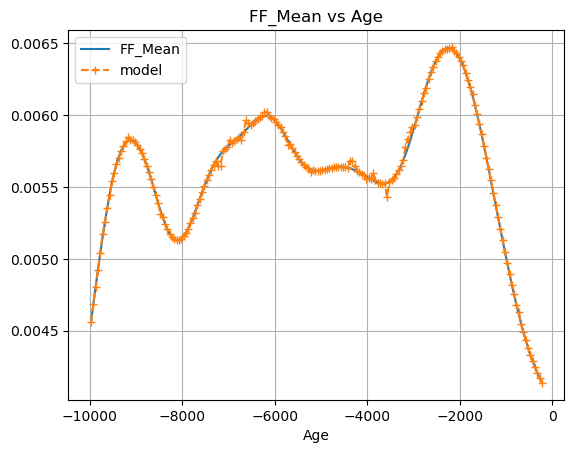

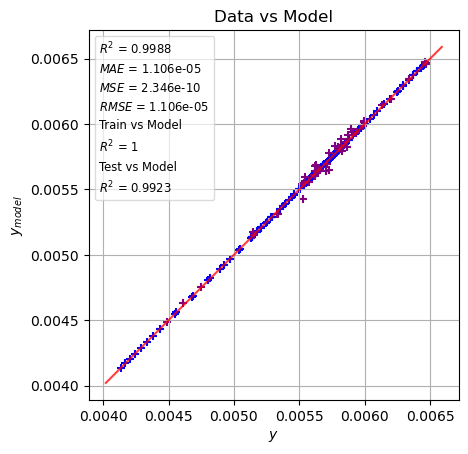

In [35]:
# feats=df_all.columns[1:22].append(df_all.columns[25:-3]).values
# feats=df_all.columns[1:22].append(df_all.columns[25:-3]).values
feats=(df_all.columns[1:22].append(df_all.columns[25:46])).append(df_all.columns[49:]).values

df=df_all
df=df.dropna()

y_target='FF_Mean' # 'FS_Mean' , 'BB_Mean' , 'FF_Mean'

[df_model, df_model_train,y_pred, y_train, y_test, b, coeff_df, [r2,mae,mse,rmse],X_scaled] = LinearRegression_sklearn(df_data=df,X_features=feats, y_target_name=y_target,split_random=True)



# figure
df_dataa=df[1:]
fig, ax = plt.subplots()
df_dataa.plot(x='Age',y=y_target,ax=ax)
ax.plot(df_dataa['Age'],b+df_model,label='model',marker='+',linestyle='--')
# ax.plot(df_dataa['Age'],b_mean+df_model_stab,label='model stability',marker='+',linestyle='--')
# ax.fill_between(df_dataa['Age'],y1=b_mean+df_model_stab_min,y2=b_mean+df_model_stab_max,alpha=0.5)

ax.legend()
ax.set_title(y_target +' vs Age')
ax.grid()

fig, ax = plt.subplots()
# ax.scatter(x=y,y=b+df_model,marker='+')
ax.scatter(x=y_train,y=b+df_model_train,marker='+',color='b',label='train')
ax.scatter(x=y_test,y=y_pred,marker='+',color='purple',label='test')
ax.set_xlabel(r'$y$')
ax.set_ylabel(r'$y_{model}$')
ax.set_title('Data vs Model')
ax.legend()
ax.set_aspect('equal',adjustable='box')
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
# now plot both limits against eachother
ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
ax.grid()
# Calculate and print R^2 score.
# r2 = r2_score(y, b+df_model)
# mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]
handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                lw=0, alpha=0)] * 8
# create the corresponding number of labels (= the text you want to display)
labels = []#"R-squared: {r2}"
labels.append('$R^2$ = {0:.4g}'.format(r2) )
labels.append('$MAE$ = {0:.4g}'.format(mae) )
labels.append('$MSE$ = {0:.4g}'.format(mse) )
labels.append('$RMSE$ = {0:.4g}'.format(rmse) )
labels.append('Train vs Model' )
r2 = r2_score(y_train, b+df_model_train)
labels.append('$R^2$ = {0:.4g}'.format(r2) )
labels.append('Test vs Model' )
r2 = r2_score(y_test, y_pred)
labels.append('$R^2$ = {0:.4g}'.format(r2) )
# create the legend, supressing the blank space of the empty line symbol and the
# padding between symbol and label by setting handlelenght and handletextpad
ax.legend(handles, labels, loc='best', fontsize='small', 
        fancybox=True, framealpha=0.7, 
        handlelength=0, handletextpad=0)


<Axes: >

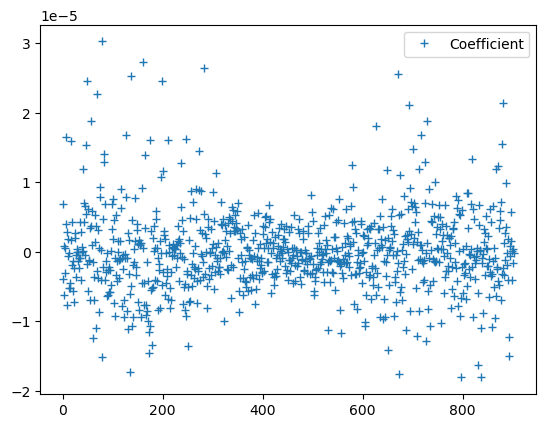

In [36]:
coeff_df.plot(y="Coefficient",marker='+',linestyle='')

,Feature,Coefficient
0,Abies,6.835390e-06
1,Cupressaceae,-3.960331e-06
2,Larix,8.470351e-07
3,Picea,-6.141825e-06
4,Pinus,-3.066384e-06
...,...,...
898,Aquatics_diff_PRECT_diff,1.085371e-07
899,Aquatics_diff_human_diff,-4.043946e-06
900,TS_diff_PRECT_diff,-1.620549e-06
901,TS_diff_human_diff,4.128439e-07


In [49]:
coeff_df.sort_values(by='Coefficient',ascending=False).head(10)

,Feature,Coefficient
79,Abies_Aquatics_diff,0.000030
161,Larix_human_diff,0.000027
282,Betula_Poaceae,0.000026
671,PRECT_human_diff,0.000026
136,Larix_Poaceae,0.000025
48,Abies_Populus,0.000025
199,Picea_human_diff,0.000025
69,Abies_Populus_diff,0.000023
881,Asteraceae_diff_human_diff,0.000021
692,human_human_diff,0.000021


In [48]:
ddf=coeff_df
ddf['Coefficient']=abs(ddf['Coefficient'])
ddf.sort_values(by='Coefficient',ascending=False).head(10)

,Feature,Coefficient
79,Abies_Aquatics_diff,0.000030
161,Larix_human_diff,0.000027
282,Betula_Poaceae,0.000026
671,PRECT_human_diff,0.000026
136,Larix_Poaceae,0.000025
48,Abies_Populus,0.000025
199,Picea_human_diff,0.000025
69,Abies_Populus_diff,0.000023
881,Asteraceae_diff_human_diff,0.000021
692,human_human_diff,0.000021


### filtre features prépondérantes


In [40]:
coeff_maj=coeff_df[abs(coeff_df.Coefficient) > np.percentile(abs(coeff_df.Coefficient.values),95)]
coeff_maj

,Feature,Coefficient
6,Betula,0.000016
16,Poaceae,0.000016
47,Abies_Betula,0.000015
48,Abies_Populus,0.000025
57,Abies_Poaceae,0.000019
61,Abies_human,-0.000012
69,Abies_Populus_diff,0.000023
78,Abies_Poaceae_diff,-0.000015
79,Abies_Aquatics_diff,0.000030
82,Abies_human_diff,0.000013


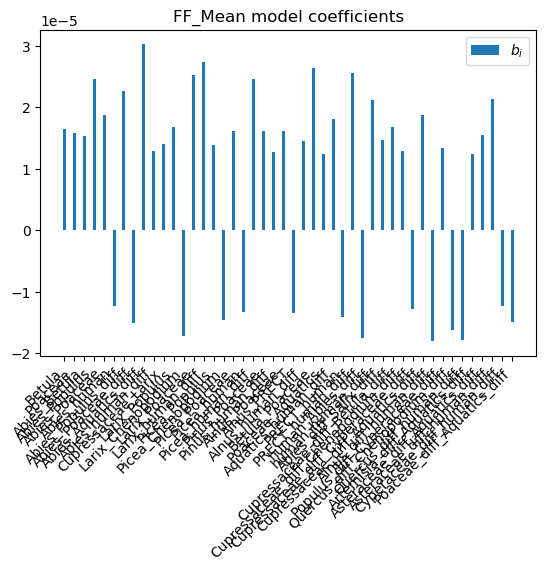

In [41]:
feats=coeff_maj.Feature
xticc=feats

fig, ax = plt.subplots()

feature = feats

v1 = coeff_maj.Coefficient.values
# v2 = coeff_maj.Coefficient[21:42].values
# v3 = coeff_df.Coefficient[-6:].values


w, x1 = 0.6, np.arange(len(v1))

ax.bar(x1 , v1, w/2, label='$b_i$')
# ax.bar(x1 , v2, w/2, label='$c_i$') # + w/3

# w, x = 0.3, np.arange(len(v1),len(v1)+6)
# ax.bar(x[:6] + w/2, v3, w, label='Pdt. i-1')

ax.set_xticks(x1, feats)
# plt.ylabel('Va')
ax.set_title(y_target + ' model coefficients')
ax.legend()


# ax.bar(FF_coeff.Feature,[FF_coeff.Coefficient,FF_coeff_smooth.Coefficient])
fig.autofmt_xdate(rotation=45)

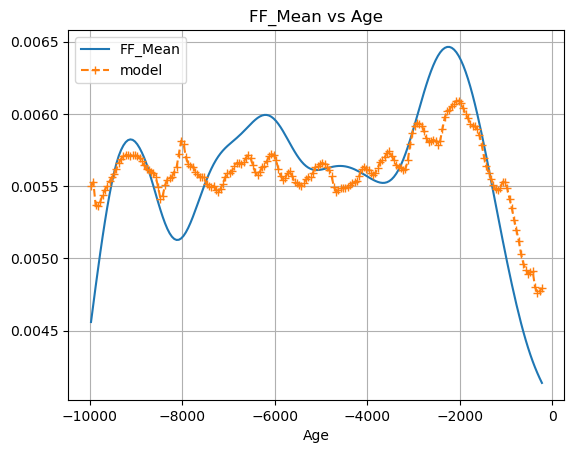

In [42]:
xx=X_scaled

df_model=xx[feats]

# multiply all columns with their respective coefficient
for i in range(len(coeff_maj)):
    df_model.iloc[:,i] = X_scaled[feats].iloc[:,i]*coeff_maj.Coefficient.values[i]
# add all columns 
df_model = df_model.sum(axis=1)


fig, ax = plt.subplots()
df_dataa.plot(x='Age',y=y_target,ax=ax)
ax.plot(df_dataa['Age'],b+df_model,label='model',marker='+',linestyle='--')
ax.legend()
ax.set_title(y_target +' vs Age')
ax.grid()

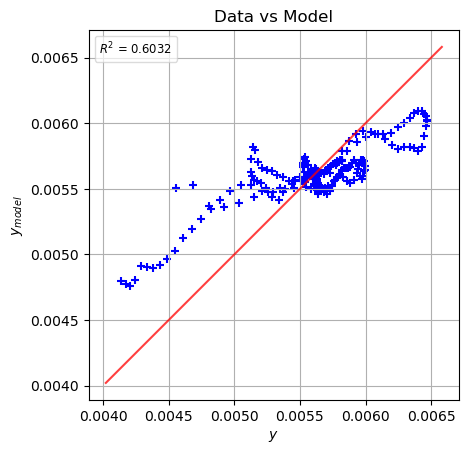

In [52]:
fig, ax = plt.subplots()
# ax.scatter(x=y,y=b+df_model,marker='+')
ax.scatter(x=df_dataa[y_target],y=b+df_model,marker='+',color='b',label='train')
# ax.scatter(x=y_test,y=y_pred,marker='+',color='purple',label='test')
ax.set_xlabel(r'$y$')
ax.set_ylabel(r'$y_{model}$')
ax.set_title('Data vs Model')
ax.legend()
ax.set_aspect('equal',adjustable='box')
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
# now plot both limits against eachother
ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
ax.grid()
# Calculate and print R^2 score.
r2 = r2_score(df_dataa[y_target], b+df_model)
# mae,mse,rmse=abs(cross_score(model,X_scaled,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]
handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                lw=0, alpha=0)] * 8
# create the corresponding number of labels (= the text you want to display)
labels = []#"R-squared: {r2}"
labels.append('$R^2$ = {0:.4g}'.format(r2) )
# labels.append('$MAE$ = {0:.4g}'.format(mae) )
# labels.append('$MSE$ = {0:.4g}'.format(mse) )
# labels.append('$RMSE$ = {0:.4g}'.format(rmse) )
# labels.append('Train vs Model' )
# r2 = r2_score(y_train, b+df_model_train)
# labels.append('$R^2$ = {0:.4g}'.format(r2) )
# labels.append('Test vs Model' )
# r2 = r2_score(y_test, y_pred)
# labels.append('$R^2$ = {0:.4g}'.format(r2) )
# create the legend, supressing the blank space of the empty line symbol and the
# padding between symbol and label by setting handlelenght and handletextpad
ax.legend(handles, labels, loc='best', fontsize='small', 
        fancybox=True, framealpha=0.7, 
        handlelength=0, handletextpad=0)

## prediction

C:\Users\leoge\AppData\Local\Temp\ipykernel_20176\2836037675.py:82: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abs(cross_score(model,X,y)).mean()[1],
C:\Users\leoge\AppData\Local\Temp\ipykernel_20176\2836037675.py:83: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abs(cross_score(model,X,y)).mean()[2],
C:\Users\leoge\AppData\Local\Temp\ipykernel_20176\2836037675.py:84: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abs(cross_score(

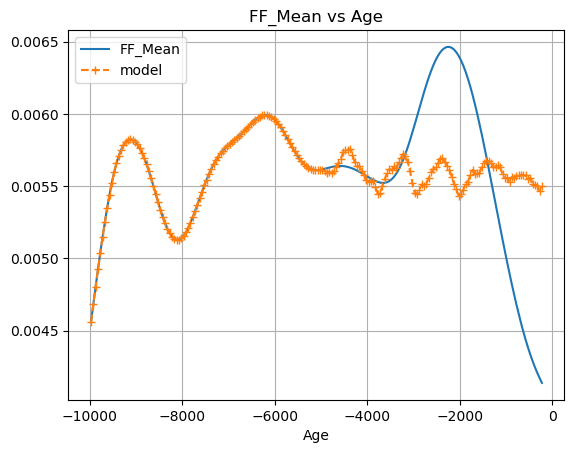

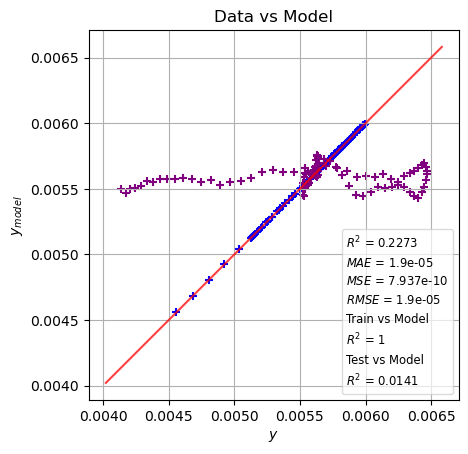

In [18]:
# feats=df_all.columns[1:22].append(df_all.columns[25:-3]).values
# feats=df_all.columns[1:22].append(df_all.columns[25:-3]).values
feats=(df_all.columns[1:22].append(df_all.columns[25:46])).append(df_all.columns[49:]).values

df=df_all
df=df.dropna()

y_target='FF_Mean' # 'FS_Mean' , 'BB_Mean' , 'FF_Mean'

[df_model, df_model_train,y_pred, y_train, y_test, b, coeff_df, [r2,mae,mse,rmse],X_scaled] = LinearRegression_sklearn(df_data=df,X_features=feats, y_target_name=y_target,split_random=False, time_split=100)



# figure
df_dataa=df[1:]
fig, ax = plt.subplots()
df_dataa.plot(x='Age',y=y_target,ax=ax)
ax.plot(df_dataa['Age'],b+df_model,label='model',marker='+',linestyle='--')
# ax.plot(df_dataa['Age'],b_mean+df_model_stab,label='model stability',marker='+',linestyle='--')
# ax.fill_between(df_dataa['Age'],y1=b_mean+df_model_stab_min,y2=b_mean+df_model_stab_max,alpha=0.5)

ax.legend()
ax.set_title(y_target +' vs Age')
ax.grid()

fig, ax = plt.subplots()
# ax.scatter(x=y,y=b+df_model,marker='+')
ax.scatter(x=y_train,y=b+df_model_train,marker='+',color='b',label='train')
ax.scatter(x=y_test,y=y_pred,marker='+',color='purple',label='test')
ax.set_xlabel(r'$y$')
ax.set_ylabel(r'$y_{model}$')
ax.set_title('Data vs Model')
ax.legend()
ax.set_aspect('equal',adjustable='box')
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
# now plot both limits against eachother
ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
ax.grid()
# Calculate and print R^2 score.
# r2 = r2_score(y, b+df_model)
# mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]
handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                lw=0, alpha=0)] * 8
# create the corresponding number of labels (= the text you want to display)
labels = []#"R-squared: {r2}"
labels.append('$R^2$ = {0:.4g}'.format(r2) )
labels.append('$MAE$ = {0:.4g}'.format(mae) )
labels.append('$MSE$ = {0:.4g}'.format(mse) )
labels.append('$RMSE$ = {0:.4g}'.format(rmse) )
labels.append('Train vs Model' )
r2 = r2_score(y_train, b+df_model_train)
labels.append('$R^2$ = {0:.4g}'.format(r2) )
labels.append('Test vs Model' )
r2 = r2_score(y_test, y_pred)
labels.append('$R^2$ = {0:.4g}'.format(r2) )
# create the legend, supressing the blank space of the empty line symbol and the
# padding between symbol and label by setting handlelenght and handletextpad
ax.legend(handles, labels, loc='best', fontsize='small', 
        fancybox=True, framealpha=0.7, 
        handlelength=0, handletextpad=0)


In [19]:
coeff_df[:21]

,Feature,Coefficient
0,Abies,-1.032392e-06
1,Cupressaceae,-1.560119e-06
2,Larix,-6.689122e-07
3,Picea,6.447124e-07
4,Pinus,6.123371e-06
5,Alnus,1.543701e-06
6,Betula,9.830267e-07
7,Populus,-6.880272e-08
8,Quercus,4.070089e-06
9,Salix,-1.041119e-06


<Axes: >

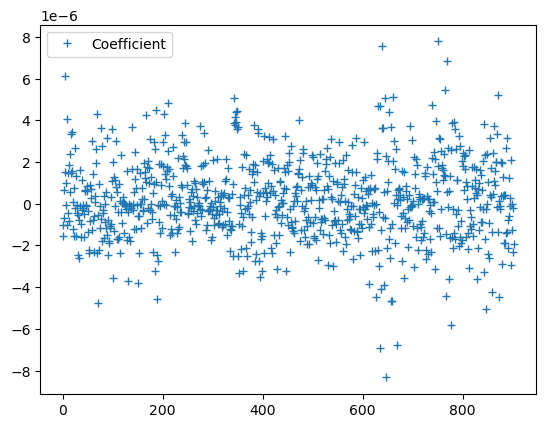

In [20]:
coeff_df.plot(marker='+',linestyle='')

In [21]:
coeff_df[42:]

,Feature,Coefficient
42,Abies_Cupressaceae,-1.573164e-06
43,Abies_Larix,-4.679045e-07
44,Abies_Picea,6.551843e-07
45,Abies_Pinus,6.100870e-07
46,Abies_Alnus,-8.085861e-08
...,...,...
898,Aquatics_diff_PRECT_diff,-1.242447e-06
899,Aquatics_diff_human_diff,3.789431e-10
900,TS_diff_PRECT_diff,-2.176784e-07
901,TS_diff_human_diff,-2.318784e-06
